# Non-Paired Bayesian A/B Model Comparison

## Simulate data & fit model

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from bayesprop.resources.bayes_nonpaired import NonPairedBayesPropTest, beta_diff_pdf
from bayesprop.utils.utils import simulate_nonpaired_scores

IMG_DIR = Path("../../docs/mkdocs/docs/images/non-paired")
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ── Simulate data ────────────────────────────────────────────────────
sim = simulate_nonpaired_scores(N=150, theta_A=0.80, theta_B=0.60, seed=42)

y_A = sim.y_A
y_B = sim.y_B

print(f"True θ_A = {sim.theta_A:.2f},  θ_B = {sim.theta_B:.2f},  Δ = {sim.theta_A - sim.theta_B:.2f}")
print(f"Observed rates: A = {y_A.mean():.3f},  B = {y_B.mean():.3f}")

# ── Fit model ────────────────────────────────────────────────────────
model = NonPairedBayesPropTest(seed=42, n_samples=50_000).fit(y_A, y_B)

s = model.summary
print(f"\nMean Δ (θ_A − θ_B) = {s.mean_delta:+.4f}")
print(f"95% CI = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"P(A > B) = {s.p_A_greater_B:.4f}")

# ── Unified decision ─────────────────────────────────────────────────
d = model.decide()
bf = d.bayes_factor
print("\n--- Unified Decision ---")
print(f"  Bayes Factor:  BF₁₀ = {bf.BF_10:.2f}  → {bf.decision}")
print(f"  Posterior Null: P(H₀|D) = {d.posterior_null.p_H0:.4f}  → {d.posterior_null.decision}")
print(f"  ROPE:          {d.rope.decision}  ({d.rope.pct_in_rope:.1%} in ROPE)")

True θ_A = 0.80,  θ_B = 0.60,  Δ = 0.20
Observed rates: A = 0.860,  B = 0.600

Mean Δ (θ_A − θ_B) = +0.2569
95% CI = [0.1610, 0.3522]
P(A > B) = 1.0000

--- Unified Decision ---
  Bayes Factor:  BF₁₀ = 64620.99  → Reject H0
  Posterior Null: P(H₀|D) = 0.0000  → Reject H0
  ROPE:          Reject H0 — A practically better  (0.0% in ROPE)


In [4]:
model.trace_summary

,mean,sd,hdi_3%,hdi_97%
theta_A,0.970601,0.016672,0.932543,0.993411
theta_B,0.921651,0.026421,0.865678,0.964042
delta,0.048951,0.031302,-0.007268,0.110588


### Posterior visualisation

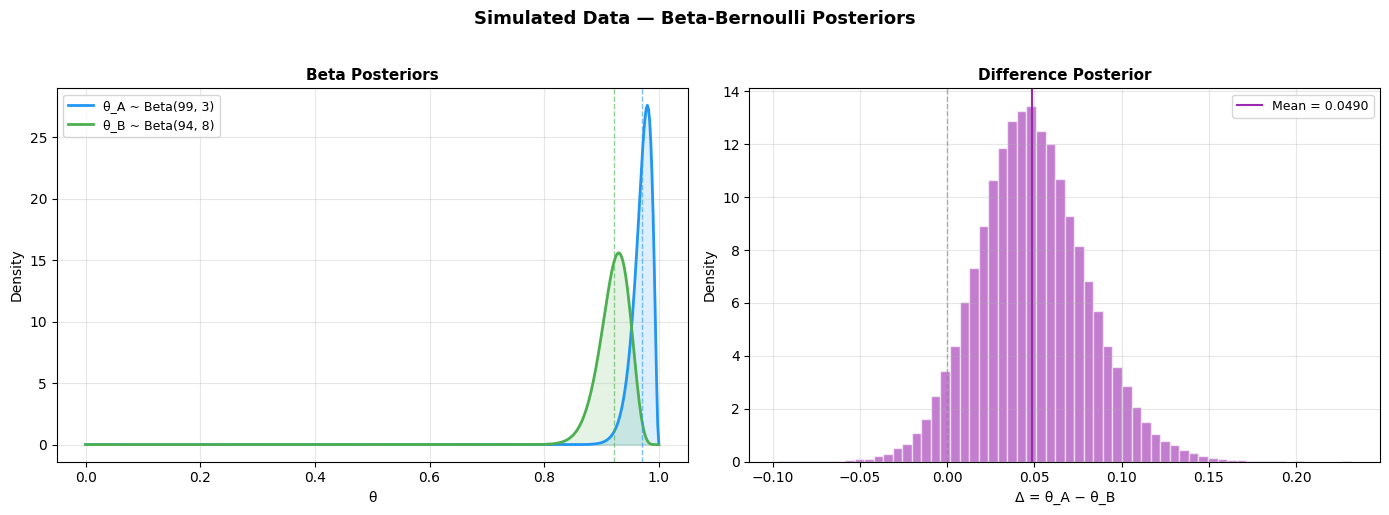

In [5]:
import matplotlib.pyplot as plt

_show = plt.show; plt.show = lambda: None
model.plot_posteriors(title="Simulated Data — Beta-Bernoulli Posteriors")
plt.savefig(IMG_DIR / "posterior_distributions.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show; plt.show()

## 4. Exact difference density via `beta_diff_pdf`

The density of $\Delta = \theta_A - \theta_B$ where $\theta_A \sim \text{Beta}(a_A, b_A)$
and $\theta_B \sim \text{Beta}(a_B, b_B)$ is computed via **log-space convolution**:

$$
f_\Delta(z) = \int_{\max(0,z)}^{\min(1,1+z)}
  f_A(x) \cdot F_B(x - z) \, dx
$$

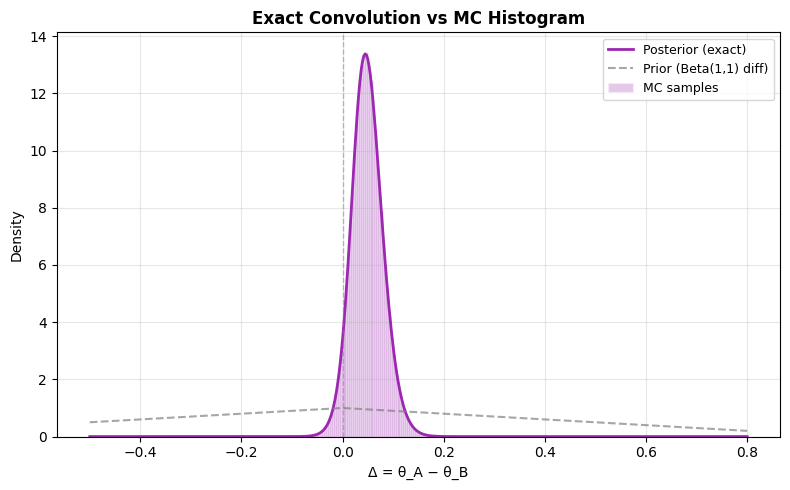

∫ f_Δ(z) dz = 1.000000  (should be ≈ 1.0)


In [6]:
from scipy.integrate import quad

z_grid = np.linspace(-0.5, 0.8, 500)

# Posterior density (exact convolution)
post_density = np.array([beta_diff_pdf(z, model.a_A, model.b_A, model.a_B, model.b_B) for z in z_grid])

# Prior density (Beta(1,1) - Beta(1,1) = uniform difference)
prior_density = np.array([beta_diff_pdf(z, 1.0, 1.0, 1.0, 1.0) for z in z_grid])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z_grid, post_density, color="#9C27B0", linewidth=2, label="Posterior (exact)")
ax.fill_between(z_grid, post_density, alpha=0.15, color="#9C27B0")
ax.plot(z_grid, prior_density, color="gray", linewidth=1.5, linestyle="--", alpha=0.7, label="Prior (Beta(1,1) diff)")

# MC histogram for comparison
ax.hist(model.delta_samples, bins=80, density=True, alpha=0.25, color="#9C27B0", edgecolor="white", label="MC samples")

ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)

ax.set_xlabel("Δ = θ_A − θ_B")
ax.set_ylabel("Density")
ax.set_title("Exact Convolution vs MC Histogram", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "exact_convolution_vs_mc.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

# Verify integration
area, _ = quad(lambda z: beta_diff_pdf(z, model.a_A, model.b_A, model.a_B, model.b_B), -0.999, 0.999)
print(f"∫ f_Δ(z) dz = {area:.6f}  (should be ≈ 1.0)")

## 5. Savage-Dickey Bayes Factor

### Hypothesis test

$$
H_0: \Delta = 0 \quad \text{vs} \quad H_1: \Delta \neq 0
$$

The Savage-Dickey density ratio computes:

$$
BF_{01} = \frac{f_\Delta^{\text{post}}(0)}{f_\Delta^{\text{prior}}(0)}
$$

In [7]:
d = model.decide()
bf = d.bayes_factor

print("Savage-Dickey Bayes Factor")
print("=" * 50)
print(f"  {'BF_01':<30} {bf.BF_01}")
print(f"  {'BF_10':<30} {bf.BF_10}")
print(f"  {'posterior_density_at_0':<30} {bf.posterior_density_at_0}")
print(f"  {'prior_density_at_0':<30} {bf.prior_density_at_0}")
print(f"  {'interpretation':<30} {bf.interpretation}")
print(f"  {'decision':<30} {bf.decision}")

Savage-Dickey Bayes Factor
  BF_01                          3.421169905955223
  BF_10                          0.29229767228435577
  posterior_density_at_0         3.421169905948381
  prior_density_at_0             0.999999999998
  interpretation                 Moderate evidence for H0
  decision                       Fail to reject H0


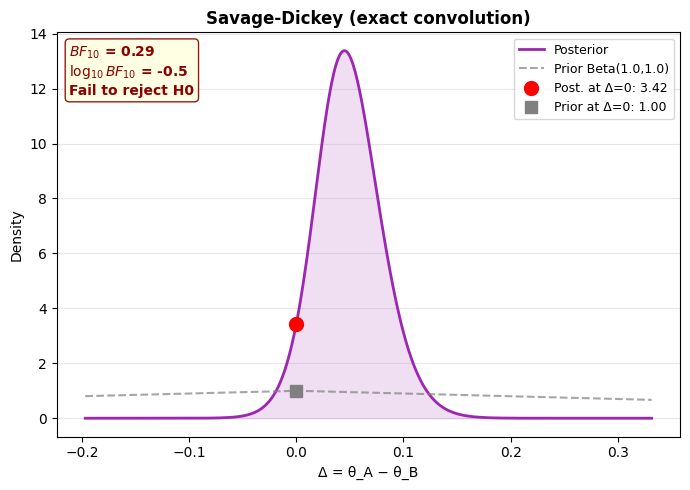

In [8]:
_show = plt.show; plt.show = lambda: None
model.plot_savage_dickey(title="Savage-Dickey (exact convolution)")
plt.savefig(IMG_DIR / "savage_dickey_bayes_factor.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show; plt.show()

### Posterior probability of Null

$$
P(H_0 \mid \text{data}) = \frac{BF_{01} \cdot \pi_0}{BF_{01} \cdot \pi_0 + (1 - \pi_0)}
$$

In [9]:
pn = d.posterior_null

print("Posterior model probabilities")
print("=" * 40)
print(f"  {'P(H0|data)':<20} {pn.p_H0:.6e}")
print(f"  {'P(H1|data)':<20} {pn.p_H1:.6e}")
print(f"  {'prior_odds':<20} {pn.prior_odds:.6e}")
print(f"  {'posterior_odds':<20} {pn.posterior_odds:.6e}")
print(f"  {'decision':<20} {pn.decision}")

Posterior model probabilities
  P(H0|data)           7.738155e-01
  P(H1|data)           2.261845e-01
  prior_odds           1.000000e+00
  posterior_odds       3.421170e+00
  decision             Undecided


### Posterior Predictive Checks

In [10]:
ppc = model.ppc_pvalues(seed=42)

print(f"{'Statistic':<25} {'Observed':>10} {'p-value':>10} {'Status':>8}")
print("-" * 55)
for stat, vals in ppc.items():
    print(f"{stat:<25} {vals.observed:>10.4f} {vals.p_value:>10.3f} {vals.status:>8}")

Statistic                   Observed    p-value   Status
-------------------------------------------------------
mean(y_A)                     0.9800      1.000       OK
mean(y_B)                     0.9300      1.000       OK
mean(y_A)-mean(y_B)           0.0500      1.000       OK


### Full summary

In [11]:
model.print_summary()

Beta-Bernoulli posterior summary (Non-Paired)
  θ_A ~ Beta(99, 3)  mean=0.9706  [n_A=100, k_A=98]
  θ_B ~ Beta(94, 8)  mean=0.9217  [n_B=100, k_B=93]
  Mean Δ (θ_A − θ_B):  0.0490
  95% CI:              [-0.0094, 0.1140]
  P(A > B):            0.9489  (MC)
  P(B > A):            0.0503  (quadrature)
  Verdict:             Tied

Savage-Dickey Bayes Factor: H0 (Δ = 0) vs H1 (Δ ≠ 0)
  Prior  density at Δ=0: 1.0000
  Post.  density at Δ=0: 3.4212
  BF_01 (for H0):        3.42
  BF_10 (against H0):    0.29
  log₁₀(BF_10):          -0.5
  → Moderate evidence for H0
  → Decision: Fail to reject H0

Posterior model probabilities (prior P(H0) = 0.5)
  P(H0|data): 7.74e-01
  P(H1|data): 0.226184

Posterior Predictive p-values
  Statistic                   Observed    p-value   Status
  -------------------------------------------------------
  mean(y_A)                     0.9800      1.000       OK
  mean(y_B)                     0.9300      1.000       OK
  mean(y_A)-mean(y_B)           0.0500 

### Prior Sensitivity check

How does the Bayes factor change with different prior strengths?

In [15]:
priors = [
    ("Uniform Beta(1,1)", 1.0, 1.0),
    ("Jeffreys Beta(0.5,0.5)", 0.5, 0.5),
    ("Informative Beta(2,2)", 2.0, 2.0),
    ("Strong Beta(5,5)", 5.0, 5.0),
]

print(f"{'Prior':<28} {'BF₁₀':>8} {'BF Decision':<20} {'ROPE Decision':<20} {'Mean Δ':>8} {'P(A>B)':>8}")
print("=" * 100)

for name, a0, b0 in priors:
    m = NonPairedBayesPropTest(alpha0=a0, beta0=b0, seed=42, n_samples=50_000).fit(y_A, y_B)
    d_i = m.decide()
    print(
        f"{name:<28} {d_i.bayes_factor.BF_10:>8.2f} {d_i.bayes_factor.decision:<20} "
        f"{d_i.rope.decision:<20} {m.summary.mean_delta:>8.4f} {m.summary.p_A_greater_B:>8.4f}"
    )

Prior                            BF₁₀ BF Decision          ROPE Decision          Mean Δ   P(A>B)
Uniform Beta(1,1)                0.29 Fail to reject H0    Undecided — CI overlaps ROPE   0.0490   0.9489
Jeffreys Beta(0.5,0.5)       16661975.97 Reject H0            Undecided — CI overlaps ROPE   0.0494   0.9595
Informative Beta(2,2)            0.30 Fail to reject H0    Undecided — CI overlaps ROPE   0.0480   0.9324
Strong Beta(5,5)                 0.36 Fail to reject H0    Undecided — CI overlaps ROPE   0.0454   0.8909


### Bayes Factor Design Analysis (BFDA) — Sample Size Planning

In frequentist testing we compute the **power** — the probability of rejecting H₀ given a true effect.
The Bayesian analog is **Bayes Factor Design Analysis**: for a hypothesised true effect
$\Delta = \theta_A - \theta_B$, simulate many datasets at each sample size and estimate the
probability of obtaining *decisive* evidence (e.g. $BF_{10} > 3$).

$$
\text{Bayesian Power}(n) = P\!\left(BF_{10} > \text{threshold} \;\middle|\; \theta_A, \theta_B, n\right)
$$

This gives a **design curve** analogous to the frequentist power curve.

In [17]:
from bayesprop.utils.utils import (
    bfda_power_curve,
    plot_bfda_power,
    plot_bfda_sensitivity,
)

# ── Use simulated rates as plug-in estimates for the true effect ──────
theta_A_hat = y_A.mean()
theta_B_hat = y_B.mean()

print("Assumed true rates (from simulated data):")
print(f"  θ_A = {theta_A_hat:.3f}")
print(f"  θ_B = {theta_B_hat:.3f}")
print(f"  True Δ = {theta_A_hat - theta_B_hat:.3f} (effect size)")
print()

# ── Compute BFDA power curve ──────────────────────────────────────────
sample_sizes = [20, 30, 50, 75, 100, 150, 200, 300, 500]

power_curve = bfda_power_curve(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    design="nonpaired",
    decision_rule="bayes_factor",
    alpha0=1.0,
    beta0=1.0,
    bf_threshold=3.0,
    n_sim=1000,
    seed=42,
)

print(f"{'n (per group)':<15} {'P(BF₁₀ > 3)':>12}")
print("-" * 28)
for n, p in power_curve.items():
    print(f"{n:<15} {p:>12.3f}")

Assumed true rates (from observed data):
  θ_A = 0.980  (pass rate, gemini-2.5-flash)
  θ_B = 0.930  (pass rate, gemini-2.0-flash)
  True Δ = 0.050 (effect size)

n (per group)    P(BF₁₀ > 3)
----------------------------
20                     0.012
30                     0.009
50                     0.014
75                     0.088
100                    0.095
150                    0.224
200                    0.349
300                    0.529
500                    0.822


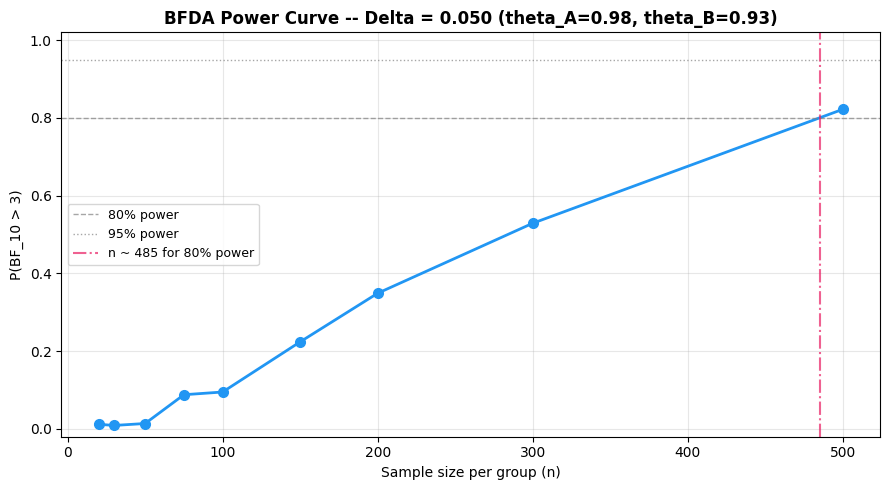

In [18]:
fig = plot_bfda_power(power_curve, theta_A_hat, theta_B_hat)
fig.savefig(IMG_DIR / "bfda_power_curve.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

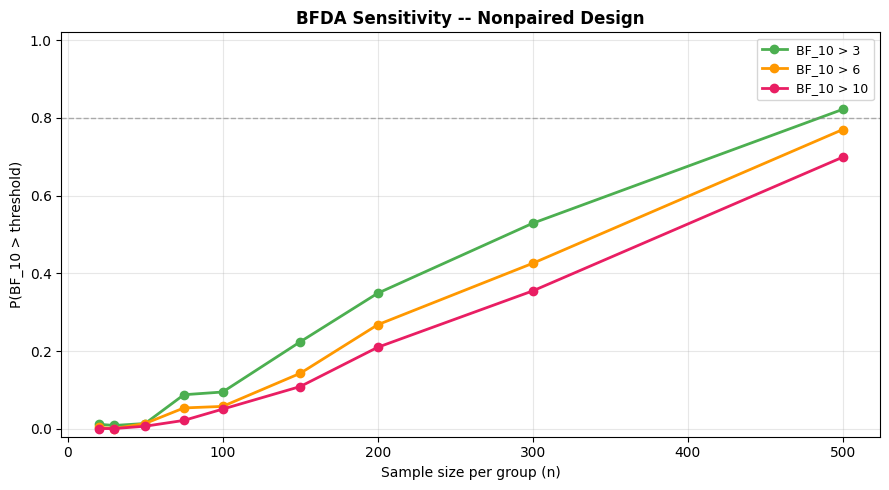

In [19]:
fig = plot_bfda_sensitivity(
    theta_A_true=theta_A_hat,
    theta_B_true=theta_B_hat,
    sample_sizes=sample_sizes,
    thresholds=[3.0, 6.0, 10.0],
    n_sim=1000,
    seed=42,
)
fig.savefig(IMG_DIR / "bfda_sensitivity_thresholds.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Visualise how the difference density concentrates with increasing sample size.

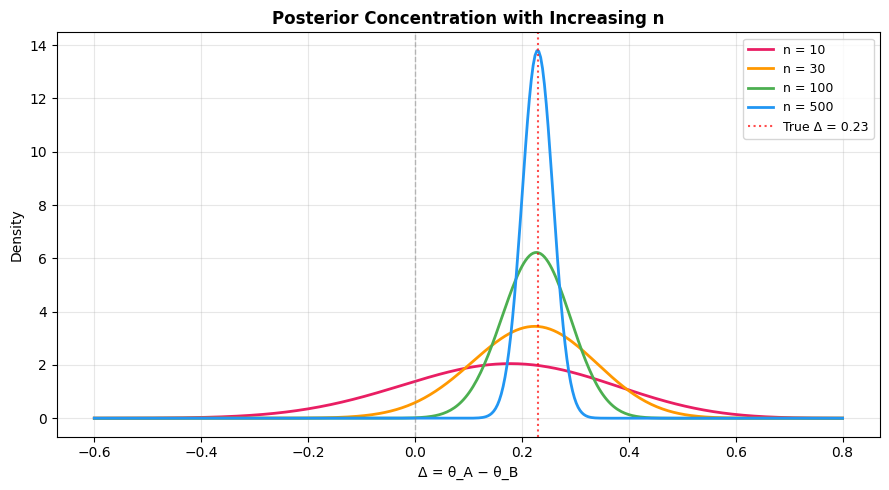

In [20]:
z_grid = np.linspace(-0.6, 0.8, 400)

fig, ax = plt.subplots(figsize=(9, 5))

sample_sizes = [10, 30, 100, 500]
colors = ["#E91E63", "#FF9800", "#4CAF50", "#2196F3"]

for n, col in zip(sample_sizes, colors, strict=False):
    # Posterior Beta params assuming true rates
    a_A = 1 + int(0.78 * n)
    b_A = 1 + n - int(0.78 * n)
    a_B = 1 + int(0.55 * n)
    b_B = 1 + n - int(0.55 * n)

    density = np.array([beta_diff_pdf(z, a_A, b_A, a_B, b_B) for z in z_grid])
    ax.plot(z_grid, density, color=col, linewidth=2, label=f"n = {n}")

ax.axvline(0.23, color="red", linestyle=":", linewidth=1.5, alpha=0.7, label="True Δ = 0.23")
ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Δ = θ_A − θ_B")
ax.set_ylabel("Density")
ax.set_title("Posterior Concentration with Increasing n", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(IMG_DIR / "posterior_concentration_sample_size.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### Null scenario (no difference)

Verify the model correctly fails to reject H\u2080 when the true rates are equal.

In [21]:
rng_null = np.random.default_rng(99)
y_A_null = rng_null.binomial(1, 0.65, size=150).astype(float)
y_B_null = rng_null.binomial(1, 0.65, size=150).astype(float)

model_null = NonPairedBayesPropTest(seed=99, n_samples=50_000).fit(y_A_null, y_B_null)

print(f"Observed rates: A={y_A_null.mean():.3f}, B={y_B_null.mean():.3f}")
print()
model_null.print_summary()

Observed rates: A=0.660, B=0.573

Beta-Bernoulli posterior summary (Non-Paired)
  θ_A ~ Beta(100, 52)  mean=0.6580  [n_A=150, k_A=99]
  θ_B ~ Beta(87, 65)  mean=0.5725  [n_B=150, k_B=86]
  Mean Δ (θ_A − θ_B):  0.0855
  95% CI:              [-0.0241, 0.1942]
  P(A > B):            0.9380  (MC)
  P(B > A):            0.0619  (quadrature)
  Verdict:             Tied

Savage-Dickey Bayes Factor: H0 (Δ = 0) vs H1 (Δ ≠ 0)
  Prior  density at Δ=0: 1.0000
  Post.  density at Δ=0: 2.1893
  BF_01 (for H0):        2.19
  BF_10 (against H0):    0.46
  log₁₀(BF_10):          -0.3
  → Anecdotal evidence for H0
  → Decision: Fail to reject H0

Posterior model probabilities (prior P(H0) = 0.5)
  P(H0|data): 6.86e-01
  P(H1|data): 0.313548

Posterior Predictive p-values
  Statistic                   Observed    p-value   Status
  -------------------------------------------------------
  mean(y_A)                     0.6600      1.000       OK
  mean(y_B)                     0.5733      1.000       OK
 

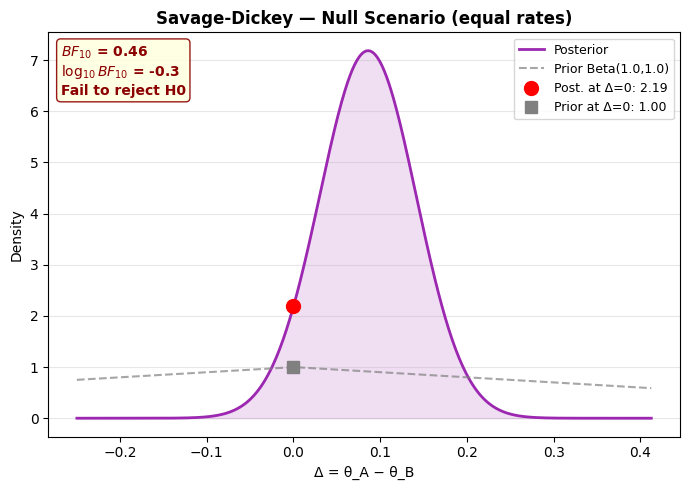

In [22]:
_show = plt.show; plt.show = lambda: None
model_null.plot_savage_dickey(title="Savage-Dickey — Null Scenario (equal rates)")
plt.savefig(IMG_DIR / "savage_dickey_null_scenario.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show = _show; plt.show()